# Recuperacion de datos
Datos extraidos de https://github.com/NOSTRODATA/conferencias_matutinas_amlo

In [1]:
import glob

# 2.1 Carga masiva desde TXT
txt_files = sorted(glob.glob("./corpus_final_txt/*.txt"))
all_text = ""

for f in txt_files:
    with open(f, 'r', encoding='utf-8') as file:
        all_text += file.read() + " "

print("Corpus cargado desde archivos procesados.")
print(f"Total de palabras (Split): {len(all_text.split())}")

Corpus cargado desde archivos procesados.
Total de palabras (Split): 15566476


## 2 Vistazo a los datos

In [2]:
import nltk
from nltk import Text, FreqDist
from nltk.corpus import stopwords
from nltk.tokenize import RegexpTokenizer, TweetTokenizer

nltk.download("stopwords", quiet=True)

# 2.1-2.4 Split
tokens_split = all_text.split()
word_count_split = len(tokens_split)
vocab_split = set(tokens_split)
ttr_split = (len(vocab_split) / word_count_split) if word_count_split else 0.0
print(f"Tokens (split): {word_count_split}")
print(f"Vocabulario (split): {len(vocab_split)}")
print(f"Riqueza vocabulario (TTR, split): {ttr_split:.4f}")

# 2.5 Minusculas
tokens_lower = all_text.lower().split()
word_count_lower = len(tokens_lower)
vocab_lower = set(tokens_lower)
ttr_lower = (len(vocab_lower) / word_count_lower) if word_count_lower else 0.0
print(f"Tokens (minusculas, split): {word_count_lower}")
print(f"Vocabulario (minusculas, split): {len(vocab_lower)}")
print(f"Riqueza vocabulario (TTR, minusculas): {ttr_lower:.4f}")
print("Comentario: al pasar a minusculas baja el vocabulario y el TTR porque se unifican formas como 'Mexico' y 'mexico'.")

# 2.6 RegexpTokenizer + Text
regexp_tokenizer = RegexpTokenizer(r"[A-Za-zÁÉÍÓÚÜÑáéíóúüñ]+")
tokens_re = regexp_tokenizer.tokenize(all_text)
text_re = Text(tokens_re)
print(f"Tokens (RegexpTokenizer): {len(tokens_re)}")
print(f"Vocabulario (RegexpTokenizer): {len(set(tokens_re))}")

# 2.7 TweetTokenizer + Text (minusculas)
tweet_tokenizer = TweetTokenizer(preserve_case=False, reduce_len=True, strip_handles=True)
tokens_tt = tweet_tokenizer.tokenize(all_text.lower())
text_tt = Text(tokens_tt)
word_tokens = [t for t in tokens_tt if t.isalpha()]
print(f"Tokens (TweetTokenizer, minusculas): {len(tokens_tt)}")
print(f"Vocabulario (TweetTokenizer, minusculas): {len(set(tokens_tt))}")
print("Comentario: TweetTokenizer conserva signos y emoticons, por eso puede aumentar el total de tokens frente al RegexpTokenizer.")

Tokens (split): 15566476
Vocabulario (split): 249742
Riqueza vocabulario (TTR, split): 0.0160
Tokens (minusculas, split): 15566476
Vocabulario (minusculas, split): 230699
Riqueza vocabulario (TTR, minusculas): 0.0148
Comentario: al pasar a minusculas baja el vocabulario y el TTR porque se unifican formas como 'Mexico' y 'mexico'.
Tokens (RegexpTokenizer): 15370728
Vocabulario (RegexpTokenizer): 102087
Tokens (TweetTokenizer, minusculas): 18068286
Vocabulario (TweetTokenizer, minusculas): 96185
Comentario: TweetTokenizer conserva signos y emoticons, por eso puede aumentar el total de tokens frente al RegexpTokenizer.


## 3 Funciones NLTK

In [4]:
# 3.1 Concordance
words_conc = ["pueblo", "corrupción", "gobierno", "salud", "seguridad"]
for w in words_conc:
    print(f"\nConcordance: {w}")
    text_tt.concordance(w, lines=5)

# 3.2 Similar y common contexts
focus_word = "corrupcion"
print(f"\nPalabras con uso similar a '{focus_word}':")
text_tt.similar(focus_word)
print("\nContextos comunes con 'mafia':")
text_tt.common_contexts([focus_word, "mafia"])
print("Comentario: las palabras similares suelen compartir temas politicos y se usan en contextos de critica o denuncia.")


Concordance: pueblo
Displaying 5 of 19676 matches:
rada con frutales . recordar que el pueblo de méxico se alimenta principalment
nseñanzas , lenguas . entonces , el pueblo de méxico tiene mucha cultura , es 
para transferir todos los fondos al pueblo y que haya desarrollo , haya trabaj
 . no puede haber gobierno rico con pueblo pobre , eso es lo que planteamos . 
 . yo tengo que estar escuchando al pueblo , porque la voz del pueblo es la vo

Concordance: corrupción
Displaying 5 of 11320 matches:
eció como norma el no permitir la corrupción y la impunidad en estos dos meses
mos emprendido para acabar con la corrupción . eso es lo bueno . lo que me due
s secretarios que no se acepta la corrupción y el influyentismo , nada de eso 
 ni amiguismo , ni nepotismo , ni corrupción , nada , y vamos a seguir limpian
a dejar de limpiar al gobierno de corrupción . faltan más de dos años y medio 

Concordance: gobierno
Displaying 5 of 29848 matches:
ogramas más importantes del actual gobierno , po

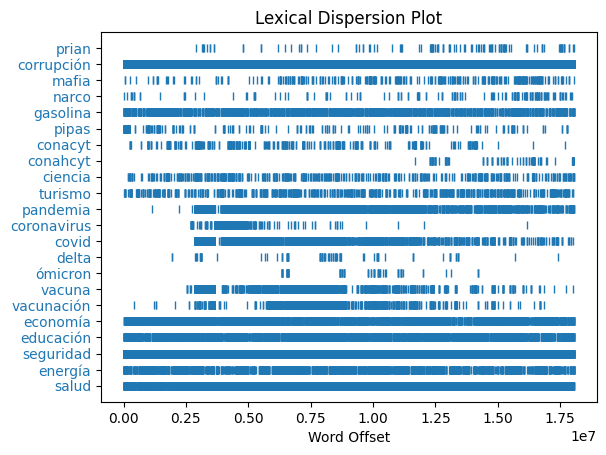

In [7]:
# 3.3 Orden cronologico y dispersion plot
import os
import re
from datetime import datetime
from nltk import Text

def extract_date(path):
    match = re.search(r"(\d{4}-\d{2}-\d{2})", os.path.basename(path))
    if match:
        return datetime.strptime(match.group(1), "%Y-%m-%d")
    return datetime.fromtimestamp(os.path.getmtime(path))

sorted_files = sorted(txt_files, key=extract_date)
tokens_time = []
for path in sorted_files:
    with open(path, "r", encoding="utf-8") as file:
        tokens_time.extend(tweet_tokenizer.tokenize(file.read().lower()))

text_time = Text(tokens_time)
words_dispersion = [
    "prian", "corrupción", "mafia", "narco", "gasolina", "pipas",
    "conacyt", "conahcyt", "ciencia", "turismo", "pandemia",
    "coronavirus", "covid", "delta", "ómicron", "vacuna",
    "vacunación", "economía", "educación", "seguridad", "energía",
    "salud"
]
text_time.dispersion_plot(words_dispersion)

Top 50 colocaciones:
estados unidos; por ciento; señor presidente; buenos días; nada más;
todos los; guardia nacional; muchas gracias; por eso; desde luego; por
ejemplo; tren maya; sin embargo; quintana roo; creo que; baja
california; poder judicial; derechos humanos; mil millones; sobre
todo; todas las; muy importante; por qué; muy bien; que que; lópez
obrador; adultos mayores; nuestro país; ver con; garcía luna; tiene
que; para que; comisión federal; los trabajadores; redes sociales; los
medios; del estado; que nos; pesos con; nuevo león; este caso; estamos
hablando; del gobierno; gobierno federal; seguridad pública; que ver;
periodo neoliberal; este año; los jóvenes; andrés manuel


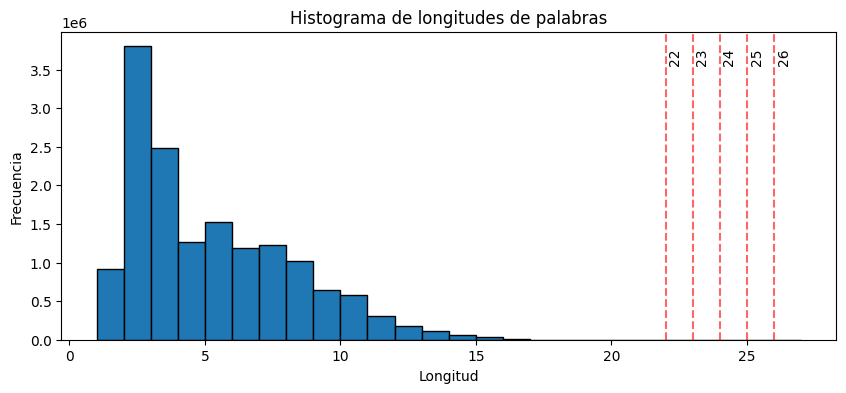


50 palabras con longitud > 8 y frecuencia > 5:
['presidente', 'importante', 'seguridad', 'información', 'secretaría', 'corrupción', 'trabajadores', 'mexicanos', 'secretario', 'situación', 'trabajando', 'presupuesto', 'elementos', 'bienestar', 'investigación', 'preguntarle', 'construcción', 'violencia', 'república', 'población', 'gobernador', 'desarrollo', 'aeropuerto', 'inversión', 'siguiente', 'hospitales', 'transformación', 'educación', 'municipios', 'democracia', 'comunicación', 'precisamente', 'autoridades', 'imagínense', 'gobiernos', 'solamente', 'protección', 'administración', 'compromiso', 'constitución', 'propósito', 'instituto', 'california', 'ciudadanos', 'secretaria', 'programas', 'inaudible', 'cualquier', 'impuestos', 'servicios']


In [8]:
# 3.4 50 colocaciones
print("Top 50 colocaciones:")
text_tt.collocations(num=50)

# 3.5 Histograma de longitudes de palabras
import matplotlib.pyplot as plt
lengths = [len(t) for t in word_tokens]
if lengths:
    fd_len = FreqDist(lengths)
    top5_lengths = sorted(fd_len.keys(), reverse=True)[:5]
    plt.figure(figsize=(10, 4))
    plt.hist(lengths, bins=range(1, max(lengths) + 2), edgecolor="black")
    for length in top5_lengths:
        plt.axvline(length, color="red", linestyle="--", alpha=0.6)
        plt.text(length + 0.1, plt.ylim()[1] * 0.9, str(length), rotation=90)
    plt.title("Histograma de longitudes de palabras")
    plt.xlabel("Longitud")
    plt.ylabel("Frecuencia")
    plt.show()
else:
    print("No hay tokens alfabeticos para histograma.")

# 3.6 Palabras largas y frecuentes
freq_words = FreqDist(word_tokens)
long_words = [w for w, c in freq_words.items() if len(w) > 8 and c > 5]
long_words_sorted = sorted(long_words, key=lambda w: (-freq_words[w], w))
print("\n50 palabras con longitud > 8 y frecuencia > 5:")
print(long_words_sorted[:50])

Grafica de ConditionalFreqDist (siguiente palabra):


<Axes: xlabel='Samples', ylabel='Counts'>

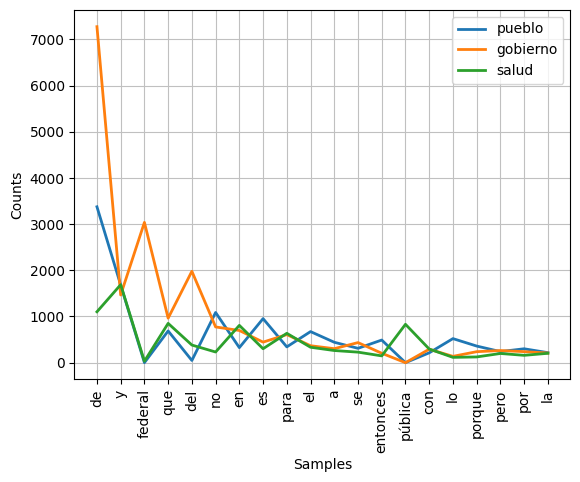

In [10]:
# 3.7 ConditionalFreqDist
from nltk import ConditionalFreqDist, bigrams

targets = ["pueblo", "gobierno", "corrupcion", "salud", "economia"]
bigrams_list = list(bigrams(word_tokens))
cfd = ConditionalFreqDist((w1, w2) for (w1, w2) in bigrams_list if w1 in targets)

# Seleccionamos los 20 siguientes tokens mas frecuentes en conjunto
sample_freq = FreqDist(w2 for (w1, w2) in bigrams_list if w1 in targets)
samples = [w for w, _ in sample_freq.most_common(20)]

print("Grafica de ConditionalFreqDist (siguiente palabra):")
cfd.plot(conditions=targets, samples=samples)

In [11]:
# 3.8 Stopwords
sw = set(stopwords.words("spanish"))
count_with_sw = len(word_tokens)
count_without_sw = len([w for w in word_tokens if w not in sw])
print(f"Tokens con stopwords: {count_with_sw}")
print(f"Tokens sin stopwords: {count_without_sw}")
print("Comentario: al quitar stopwords baja el total porque se eliminan palabras funcionales muy frecuentes.")

# 3.9 Top 300 palabras sin stopwords
freq_no_sw = FreqDist([w for w in word_tokens if w not in sw])
print("\nTop 300 palabras mas frecuentes sin stopwords:")
for w, c in freq_no_sw.most_common(300):
    print(f"{w}\t{c}")

Tokens con stopwords: 15352524
Tokens sin stopwords: 7162044
Comentario: al quitar stopwords baja el total porque se eliminan palabras funcionales muy frecuentes.

Top 300 palabras mas frecuentes sin stopwords:
presidente	54711
si	54571
entonces	50169
vamos	45873
va	45862
mil	45184
méxico	41454
aquí	32876
gobierno	29848
pues	27673
ver	26654
ahora	26294
dos	25959
bueno	23945
ahí	23842
millones	22824
caso	22686
cómo	22089
pesos	20806
país	20589
así	20100
días	19767
van	19734
pueblo	19676
ser	19537
gente	19453
usted	19254
hacer	19014
señor	18959
nacional	18955
ciento	18637
bien	16722
tres	16331
gracias	16275
años	16089
tema	15856
decir	15516
puede	15262
parte	15239
importante	15217
poder	14913
hoy	14808
mismo	14675
día	14595
hace	14498
tener	14410
salud	14374
año	14339
manera	14294
personas	14131
tiempo	14084
seguridad	13922
unidos	13767
todas	13244
buenos	13165
información	12896
luego	12713
voy	12459
además	12450
general	12416
sólo	11778
secretaría	11452
muchas	11341
corrupción	11320
aye

## 4 Otras librerias en Python
1. **spaCy**: ventaja = muy rapido y con modelos listos; desventaja = modelos grandes y menos flexible para educacion basica.
2. **transformers (Hugging Face)**: ventaja = resultados SOTA; desventaja = requiere mas recursos y ajuste de hiperparametros.

## Alternativas en otros lenguajes
1. **Java (Stanford CoreNLP)**: ventaja = robusto y completo; desventaja = pesado en memoria.
2. **R (tidytext)**: ventaja = integracion con analisis estadistico; desventaja = menos rendimiento en grandes corpus.
3. **JavaScript (natural)**: ventaja = facil de integrar en apps web; desventaja = menos modelos avanzados.